<hr>

# Chapter 05 — Monte Carlo Learning from Complete Episodes
<hr>

**Theme**: learning values and improving decisions from complete sampled experience.

This course is notebook-first, where each chapter is represented as a notebook. Each notebook is designed to be read top-to-bottom and run as you go.

### What you will learn
- How Monte Carlo methods estimate value without a transition model.
- Why Monte Carlo waits for an episode to finish before updating.
- How first-visit prediction averages returns from repeated experience.
- How state coverage affects confidence and estimation error.
- How action values and epsilon-soft exploration can improve a policy.

### Prereqs
- Chapters 01–04
- Python basics and NumPy
- Familiarity with states, policies, returns, and action values

### Estimated time
- 60–75 minutes

<br>
<br>
<hr>
<br>
<br>


# 1. Introduction

In blackjack, most actions receive no immediate reward.

You may hit several times, see several new cards, and only discover whether those decisions were good when the hand ends. A win gives `+1`, a draw gives `0`, and a loss gives `-1`.

This is exactly the setting Monte Carlo methods are built around:

1. generate a complete episode
2. observe its final outcome
3. work backwards to calculate returns
4. average those returns over repeated experience

Chapter 04 planned with a complete transition model. In blackjack, we will not list the probability of every possible next hand. We will simply play many hands and learn from what happens.

Monte Carlo therefore replaces:

```text
known transition probabilities
```

with:

```text
complete sampled episodes
```

<br>
<br>
<hr>
<br>
<br>


# 2. Core Idea

### Monte Carlo prediction in one sentence
**Estimate a state's value by averaging the returns observed after visiting that state.**

For a policy $\pi$:

$$
V^\pi(s) \approx
\text{average of returns following visits to }s.
$$

Monte Carlo methods:

- do not require transition probabilities
- learn from actual episodes
- use the full return as the target
- do not bootstrap from current value estimates
- require episodes with a defined ending

### Planning, Monte Carlo, and TD

| Method | Information used | Update timing | Bootstraps? |
|---|---|---|---|
| Value iteration | complete model | sweeps over states | yes |
| Monte Carlo | complete episodes | after termination | no |
| TD learning | sampled transitions | during an episode | yes |

Chapter 02 previewed the timing difference between Monte Carlo and TD. This chapter develops Monte Carlo into a complete prediction and control method.

<br>
<br>
<hr>
<br>
<br>


# 3. Blackjack-lite

We use a compact version of blackjack:

- cards `2–9` have their number value
- face cards count as `10`
- an ace counts as `11` when safe, otherwise `1`
- the player can **hit** or **stick**
- the dealer hits below `17` and sticks on `17` or above
- going above `21` is a bust
- rewards are `+1` for a win, `0` for a draw, and `-1` for a loss

A state is:

$$
(\text{player sum},\ \text{dealer showing},\ \text{usable ace}).
$$

A **usable ace** is currently counted as `11` without making the hand exceed `21`.

The deck is infinite: every draw samples independently from the standard card-value distribution. Natural blackjack has no special bonus.

> **Reading guidance:** the next code cell implements the game. It is environment scaffolding. Understand the rules and the `reset`/`step` interface, but the Monte Carlo update later is the code to study closely.


In [2]:
# If you're running this in a fresh environment, you only need numpy + matplotlib.
# Uncomment below as required:

# %pip install numpy
# %pip install matplotlib

from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

STICK = 0
HIT = 1
ACTIONS = (STICK, HIT)
ACTION_NAMES = {STICK: "stick", HIT: "hit"}
CARD_VALUES = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10])


class BlackjackLite:
    '''Compact episodic blackjack environment.'''

    def __init__(self):
        self.player = []
        self.dealer = []

    @staticmethod
    def draw_card(rng):
        return int(rng.choice(CARD_VALUES))

    @staticmethod
    def hand_value(cards):
        total = sum(cards)
        usable_ace = 1 in cards and total + 10 <= 21
        return (total + 10 if usable_ace else total), usable_ace

    def state(self):
        player_sum, usable_ace = self.hand_value(self.player)
        return player_sum, self.dealer[0], usable_ace

    def reset(self, rng):
        self.player = [self.draw_card(rng), self.draw_card(rng)]
        self.dealer = [self.draw_card(rng), self.draw_card(rng)]

        # Decisions below 12 are trivial: another card cannot cause a bust.
        while self.hand_value(self.player)[0] < 12:
            self.player.append(self.draw_card(rng))

        return self.state()

    def step(self, action, rng):
        if action == HIT:
            self.player.append(self.draw_card(rng))
            player_sum, _ = self.hand_value(self.player)

            if player_sum > 21:
                return None, -1.0, True
            return self.state(), 0.0, False

        while self.hand_value(self.dealer)[0] < 17:
            self.dealer.append(self.draw_card(rng))

        player_sum, _ = self.hand_value(self.player)
        dealer_sum, _ = self.hand_value(self.dealer)

        if dealer_sum > 21 or player_sum > dealer_sum:
            reward = 1.0
        elif player_sum == dealer_sum:
            reward = 0.0
        else:
            reward = -1.0

        return None, reward, True


env = BlackjackLite()
rng = np.random.default_rng(7)
example_state = env.reset(rng)

assert 12 <= example_state[0] <= 21
assert 1 <= example_state[1] <= 10
assert isinstance(example_state[2], (bool, np.bool_))
assert BlackjackLite.hand_value([1, 7]) == (18, True)
assert BlackjackLite.hand_value([1, 7, 10]) == (18, False)

print("Blackjack-lite environment ready.")


Blackjack-lite environment ready.


# 4. A Complete Episode

We begin with a fixed policy:

- hit on sums below `20`
- stick on `20` or `21`

This policy is intentionally simple. Our first task is **prediction**: estimate how valuable each state is when this policy is followed.

The episode generator below is supporting machinery. It records `(state, action, reward)` for every decision until the hand terminates.


In [6]:
def stick_on_20_policy(state, rng):
    return STICK if state[0] >= 20 else HIT


def generate_episode(env, policy, rng):
    '''Generate one complete trajectory under a policy.'''
    state = env.reset(rng)
    trajectory = []

    while True:
        action = policy(state, rng)
        next_state, reward, terminated = env.step(action, rng)
        trajectory.append((state, action, reward))

        if terminated:
            return trajectory
        state = next_state


rng = np.random.default_rng(12)
sample_episode = generate_episode(BlackjackLite(), stick_on_20_policy, rng)

print("state                 action   reward")
print("-------------------------------------")
for state, action, reward in sample_episode:
    print(f"{str(state):21s} {ACTION_NAMES[action]:7s} {reward:5.1f}")


state                 action   reward
-------------------------------------
(12, 10, False)       hit       0.0
(13, 10, False)       hit       0.0
(16, 10, False)       hit       0.0
(19, 10, False)       hit      -1.0


## 4.1 Calculate Returns Backwards

Suppose one episode produces rewards:

```text
[0, 0, +1]
```

With $\gamma=1$, every visited state receives return `+1`, because the eventual win belongs to the future of each decision.

With $\gamma<1$, earlier decisions receive a discounted return:

$$
G_t=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots
$$

The easiest implementation works backwards from the final reward.


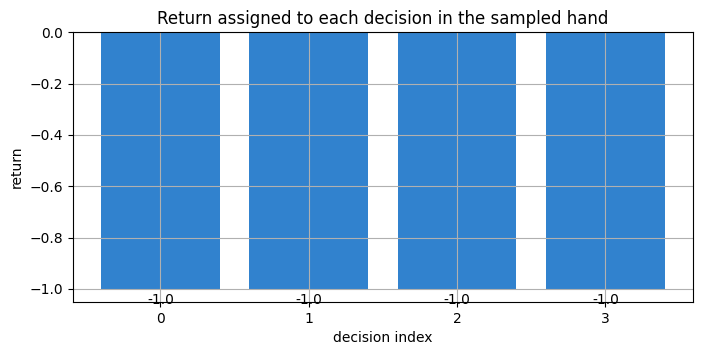

In [7]:
def returns_from_rewards(rewards, gamma=1.0):
    returns = np.zeros(len(rewards), dtype=float)
    G = 0.0

    for index in range(len(rewards) - 1, -1, -1):
        G = rewards[index] + gamma * G
        returns[index] = G

    return returns


sample_rewards = [transition[2] for transition in sample_episode]
sample_returns = returns_from_rewards(sample_rewards, gamma=1.0)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(
    np.arange(len(sample_returns)),
    sample_returns,
    color="#3182ce",
)
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_title("Return assigned to each decision in the sampled hand")
ax.set_xlabel("decision index")
ax.set_ylabel("return")
ax.set_xticks(np.arange(len(sample_returns)))
plt.show()


# 5. Core Coding Exercise: First-Visit Monte Carlo Update

In **first-visit Monte Carlo**, a state is updated only for its first occurrence in an episode.

For every first visit to state $s$:

$$
N(s) \leftarrow N(s)+1
$$

$$
V(s) \leftarrow V(s)+\frac{1}{N(s)}[G-V(s)].
$$

This is the same incremental-mean shape introduced in Chapter 01:

```text
new estimate = old estimate + step size × (target - old estimate)
```

Here, the target is the complete episode return.

> **This is the key code block for prediction.** Read the backwards return calculation and first-visit check carefully. The rest of the experiment applies this update repeatedly.


In [4]:
def first_visit_mc_update(
    trajectory,
    values,
    counts,
    gamma=1.0,
):
    '''Update state values from one complete episode.'''
    rewards = [transition[2] for transition in trajectory]
    returns = returns_from_rewards(rewards, gamma)
    visited_states = set()

    for (state, _, _), G in zip(trajectory, returns):
        if state in visited_states:
            continue

        visited_states.add(state)
        counts[state] += 1
        values[state] += (G - values[state]) / counts[state]


# A repeated state is updated only at its first occurrence.
test_state = (15, 10, False)
test_trajectory = [
    (test_state, HIT, 0.0),
    (test_state, HIT, 0.0),
    ((20, 10, False), STICK, 1.0),
]
test_values = defaultdict(float)
test_counts = defaultdict(int)
first_visit_mc_update(test_trajectory, test_values, test_counts)

assert test_counts[test_state] == 1
assert np.isclose(test_values[test_state], 1.0)
print("First-visit update checks passed.")


First-visit update checks passed.


# 6. Monte Carlo Prediction

We now play many hands using the fixed policy and repeatedly apply the first-visit update.

We record snapshots so we can see:

- how values form across the state space
- which states receive the most data
- how estimation error falls with more episodes

The training wrapper is experiment scaffolding. The learning rule remains `first_visit_mc_update`.


In [5]:
def mc_prediction(
    policy,
    n_episodes,
    gamma=1.0,
    seed=7,
    snapshot_episodes=(),
):
    rng = np.random.default_rng(seed)
    env = BlackjackLite()
    values = defaultdict(float)
    counts = defaultdict(int)
    snapshots = {}

    for episode_number in range(1, n_episodes + 1):
        trajectory = generate_episode(env, policy, rng)
        first_visit_mc_update(trajectory, values, counts, gamma)

        if episode_number in snapshot_episodes:
            snapshots[episode_number] = (
                dict(values),
                dict(counts),
            )

    return dict(values), dict(counts), snapshots


snapshot_episodes = (100, 1_000, 10_000, 50_000)
mc_values, mc_counts, prediction_snapshots = mc_prediction(
    stick_on_20_policy,
    n_episodes=50_000,
    snapshot_episodes=snapshot_episodes,
)

print(f"Estimated values for {len(mc_values)} states.")
print(f"Total first visits recorded: {sum(mc_counts.values()):,}")


Estimated values for 200 states.
Total first visits recorded: 77,830


## 6.1 Visualise the Estimated Values

Each heatmap shows estimated return under the fixed policy:

- rows are player sums
- columns are the dealer's visible card
- warmer colours are better for the player

We separate states with and without a usable ace because the same total can behave differently in those two situations.

> **Reading guidance:** the heatmap helper is plotting scaffolding. Focus on the pattern in the estimates.


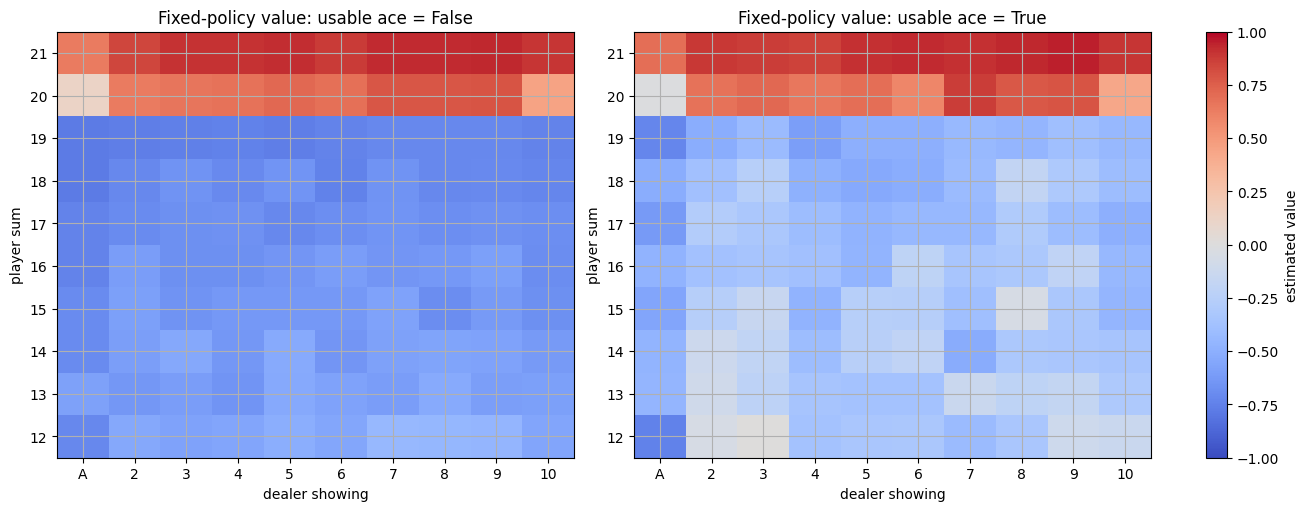

In [6]:
PLAYER_SUMS = np.arange(12, 22)
DEALER_CARDS = np.arange(1, 11)


def state_table(mapping, usable_ace, default=np.nan):
    table = np.full((len(PLAYER_SUMS), len(DEALER_CARDS)), default, dtype=float)
    for row, player_sum in enumerate(PLAYER_SUMS):
        for col, dealer_card in enumerate(DEALER_CARDS):
            table[row, col] = mapping.get(
                (int(player_sum), int(dealer_card), usable_ace),
                default,
            )
    return table


def draw_heatmap(ax, table, title, cmap="coolwarm", vmin=None, vmax=None):
    image = ax.imshow(
        table,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("dealer showing")
    ax.set_ylabel("player sum")
    ax.set_xticks(np.arange(10), labels=["A", "2", "3", "4", "5", "6", "7", "8", "9", "10"])
    ax.set_yticks(np.arange(10), labels=PLAYER_SUMS)
    return image


fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, usable_ace in zip(axs, [False, True]):
    table = state_table(mc_values, usable_ace)
    image = draw_heatmap(
        ax,
        table,
        f"Fixed-policy value: usable ace = {usable_ace}",
        vmin=-1,
        vmax=1,
    )
fig.colorbar(image, ax=axs, label="estimated value")
plt.show()


### What you should notice

- High player sums are more valuable because the fixed policy sticks.
- Strong dealer cards make many states less favourable.
- A usable ace generally makes hitting safer.
- The heatmaps are estimates from experience, not values calculated from a transition model.

<br>
<br>
<hr>
<br>
<br>


## 6.2 Coverage: Where Did the Data Come From?

Monte Carlo estimates are only as reliable as their samples.

Some states occur frequently. Others are rare, especially particular usable-ace combinations. A value heatmap without visit counts can hide that difference.


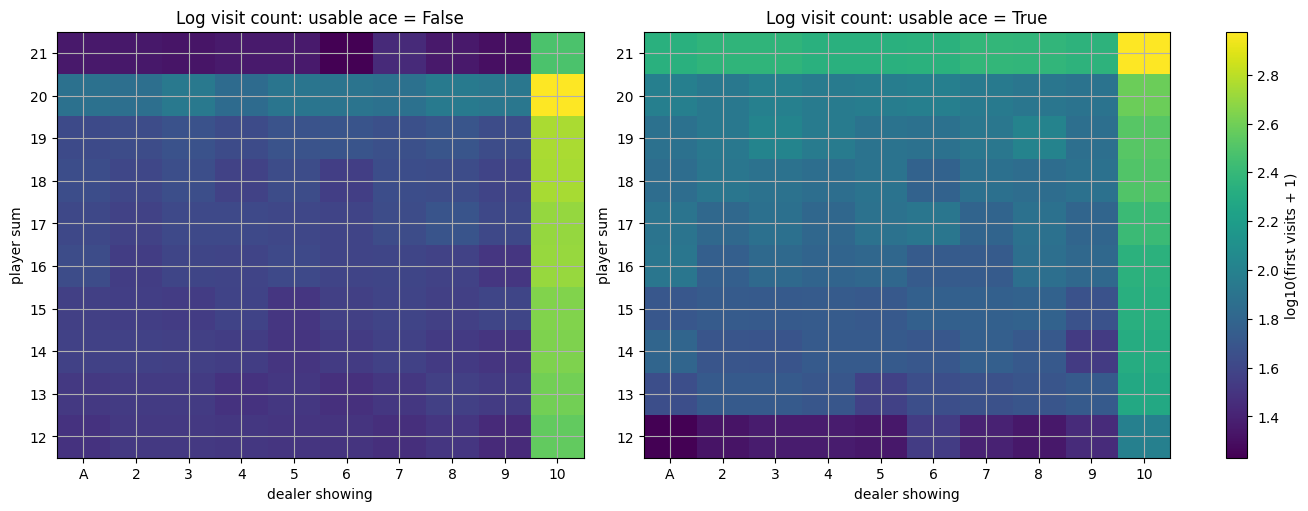

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, usable_ace in zip(axs, [False, True]):
    count_table = state_table(mc_counts, usable_ace, default=0.0)
    image = draw_heatmap(
        ax,
        np.log10(count_table + 1),
        f"Log visit count: usable ace = {usable_ace}",
        cmap="viridis",
    )
fig.colorbar(image, ax=axs, label="log10(first visits + 1)")
plt.show()


# 7. Does More Experience Improve the Estimate?

The exact values are not available to the learner. For teaching purposes, we create a **large-sample reference estimate** using a separate seeded simulation.

This reference is still an approximation, not ground truth. It is simply much less noisy than estimates based on a few hundred or few thousand hands.

We measure root mean squared error over states that received at least 500 reference visits.


   100 episodes: RMSE=0.727
 1,000 episodes: RMSE=0.260
10,000 episodes: RMSE=0.066
50,000 episodes: RMSE=0.037


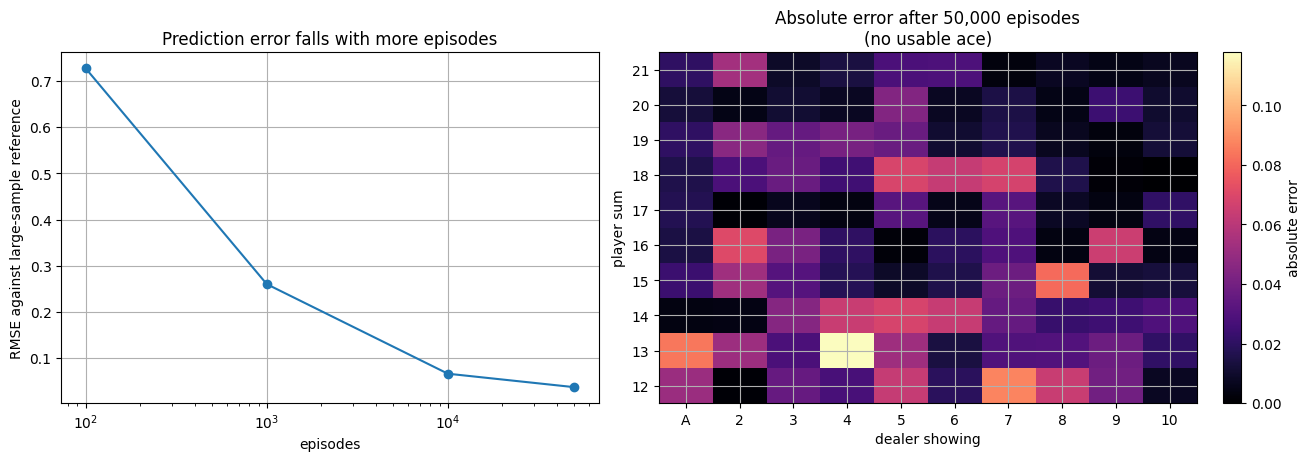

In [8]:
reference_values, reference_counts, _ = mc_prediction(
    stick_on_20_policy,
    n_episodes=200_000,
    seed=99,
)
reference_states = [
    state
    for state, count in reference_counts.items()
    if count >= 500
]


def rmse_against_reference(values, reference_values, states):
    errors = [
        values.get(state, 0.0) - reference_values[state]
        for state in states
    ]
    return float(np.sqrt(np.mean(np.square(errors))))


snapshot_errors = [
    rmse_against_reference(
        prediction_snapshots[episode][0],
        reference_values,
        reference_states,
    )
    for episode in snapshot_episodes
]

for episode, error in zip(snapshot_episodes, snapshot_errors):
    print(f"{episode:>6,} episodes: RMSE={error:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

axs[0].plot(snapshot_episodes, snapshot_errors, marker="o")
axs[0].set_xscale("log")
axs[0].set_title("Prediction error falls with more episodes")
axs[0].set_xlabel("episodes")
axs[0].set_ylabel("RMSE against large-sample reference")

final_errors = {
    state: abs(mc_values.get(state, 0.0) - reference_values[state])
    for state in reference_states
}
error_table = state_table(final_errors, usable_ace=False)
image = draw_heatmap(
    axs[1],
    error_table,
    "Absolute error after 50,000 episodes\n(no usable ace)",
    cmap="magma",
    vmin=0,
)
fig.colorbar(image, ax=axs[1], label="absolute error")

plt.show()

assert snapshot_errors[-1] < snapshot_errors[0]


### Sampling variance

Monte Carlo targets are unbiased samples of return, but they can be noisy.

One hand may win and another may lose from the same state. Averaging reduces this variation, but rare states need many total episodes before receiving many visits.

This is why Monte Carlo learning can be statistically expensive even when its update rule is simple.

<br>
<br>
<hr>
<br>
<br>


# 8. From Prediction to Control

Prediction answers:

> How good are states under this fixed policy?

Control asks:

> How can the agent improve its decisions?

State values are not enough to choose between `hit` and `stick`. We therefore estimate action values:

$$
Q(s,a)\approx
\text{average return after taking action }a\text{ in state }s.
$$

The agent follows an **epsilon-soft** policy:

- with probability $\epsilon$, choose a random action
- otherwise, choose the action with the largest current Q-value

Exploration ensures both actions continue to receive data.

> **This is the key code block for control.** It combines complete episodes, first-visit state-action updates, and epsilon-soft action selection.


In [9]:
def epsilon_soft_action(q_values, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.choice(ACTIONS))
    return int(np.argmax(q_values[state]))


def mc_control(
    n_episodes=100_000,
    epsilon=0.1,
    gamma=1.0,
    seed=7,
):
    rng = np.random.default_rng(seed)
    env = BlackjackLite()
    q_values = defaultdict(lambda: np.zeros(len(ACTIONS)))
    counts = defaultdict(lambda: np.zeros(len(ACTIONS), dtype=int))
    episode_rewards = np.zeros(n_episodes)

    for episode_number in range(n_episodes):
        state = env.reset(rng)
        trajectory = []

        while True:
            action = epsilon_soft_action(
                q_values,
                state,
                epsilon,
                rng,
            )
            next_state, reward, terminated = env.step(action, rng)
            trajectory.append((state, action, reward))

            if terminated:
                break
            state = next_state

        rewards = [transition[2] for transition in trajectory]
        returns = returns_from_rewards(rewards, gamma)
        visited_pairs = set()

        for (state, action, _), G in zip(trajectory, returns):
            pair = (state, action)
            if pair in visited_pairs:
                continue

            visited_pairs.add(pair)
            counts[state][action] += 1
            q_values[state][action] += (
                G - q_values[state][action]
            ) / counts[state][action]

        episode_rewards[episode_number] = rewards[-1]

    policy = {
        state: int(np.argmax(action_values))
        for state, action_values in q_values.items()
    }
    return q_values, policy, counts, episode_rewards


q_values, learned_policy, action_counts, control_rewards = mc_control()
print(f"Learned action values for {len(q_values)} states.")


Learned action values for 200 states.


## 8.1 Learning Curve

Individual blackjack outcomes remain noisy throughout training. A rolling average makes the broad improvement easier to see.

The curve is expected return under an exploratory policy, so it remains below the performance of the final greedy policy evaluated later.


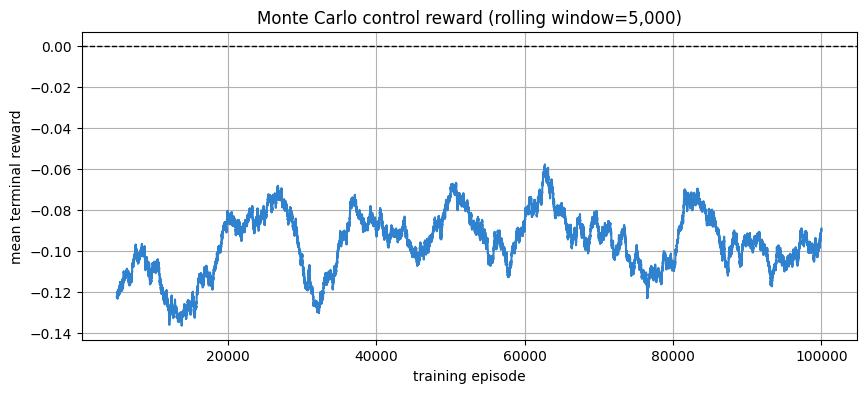

In [10]:
def rolling_mean(values, window=5_000):
    values = np.asarray(values, dtype=float)
    return np.convolve(values, np.ones(window) / window, mode="valid")


window = 5_000
smoothed_rewards = rolling_mean(control_rewards, window)
episodes = np.arange(window, len(control_rewards) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(episodes, smoothed_rewards, color="#3182ce")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Monte Carlo control reward (rolling window={window:,})")
ax.set_xlabel("training episode")
ax.set_ylabel("mean terminal reward")
plt.show()


## 8.2 The Learned Hit/Stick Policy

Each square now displays the greedy action from the learned Q-values:

- `H` means hit
- `S` means stick

The boundary is learned from sampled outcomes. It was not written into the agent.


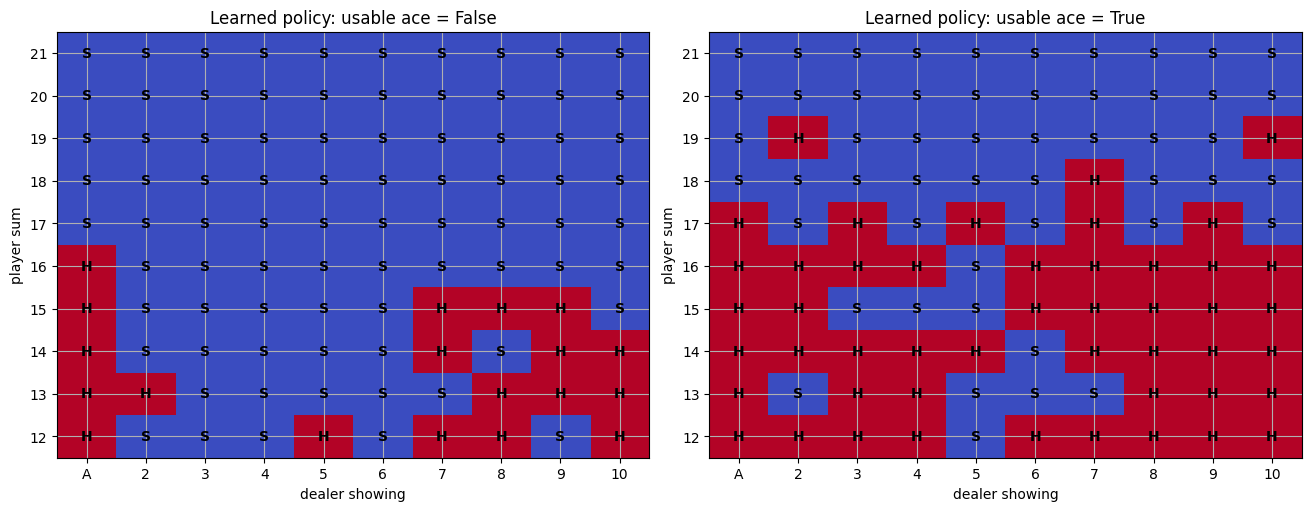

In [11]:
def policy_table(policy, usable_ace):
    table = np.full((10, 10), np.nan)
    for row, player_sum in enumerate(PLAYER_SUMS):
        for col, dealer_card in enumerate(DEALER_CARDS):
            state = (int(player_sum), int(dealer_card), usable_ace)
            if state in policy:
                table[row, col] = policy[state]
    return table


fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, usable_ace in zip(axs, [False, True]):
    table = policy_table(learned_policy, usable_ace)
    ax.imshow(table, origin="lower", aspect="auto", cmap="coolwarm", vmin=0, vmax=1)

    for row in range(10):
        for col in range(10):
            if np.isfinite(table[row, col]):
                ax.text(
                    col,
                    row,
                    "H" if table[row, col] == HIT else "S",
                    ha="center",
                    va="center",
                    weight="bold",
                )

    ax.set_title(f"Learned policy: usable ace = {usable_ace}")
    ax.set_xlabel("dealer showing")
    ax.set_ylabel("player sum")
    ax.set_xticks(np.arange(10), labels=["A", "2", "3", "4", "5", "6", "7", "8", "9", "10"])
    ax.set_yticks(np.arange(10), labels=PLAYER_SUMS)

plt.show()


## 8.3 Why Does the Policy Choose Each Action?

The next heatmaps show:

$$
Q(s,\text{hit})-Q(s,\text{stick}).
$$

- positive values favour hit
- negative values favour stick
- values near zero indicate a close or uncertain decision

This connects the visible policy boundary to the learned action values underneath it.


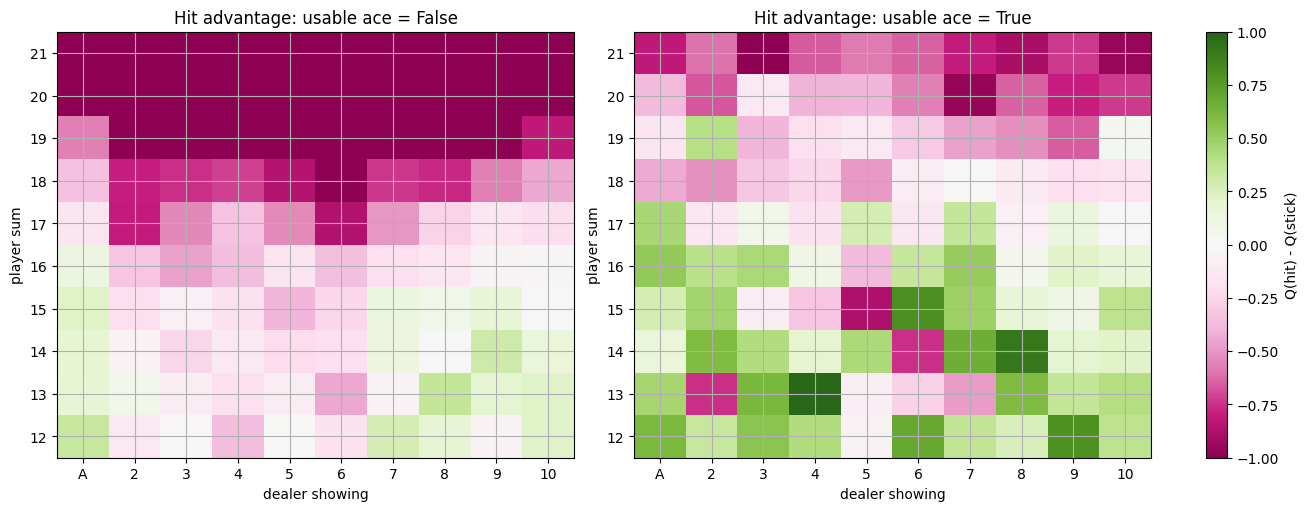

In [12]:
action_advantage = {
    state: action_values[HIT] - action_values[STICK]
    for state, action_values in q_values.items()
}

fig, axs = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, usable_ace in zip(axs, [False, True]):
    advantage_table = state_table(action_advantage, usable_ace)
    image = draw_heatmap(
        ax,
        advantage_table,
        f"Hit advantage: usable ace = {usable_ace}",
        cmap="PiYG",
        vmin=-1,
        vmax=1,
    )
fig.colorbar(image, ax=axs, label="Q(hit) - Q(stick)")
plt.show()


# 9. Fixed Policy vs Learned Policy

Training used exploration and changed the Q-table. Evaluation now freezes the learned values and follows the greedy policy without exploratory actions.

We compare:

- the original rule: stick only on `20` or `21`
- the learned greedy policy

> **Reading guidance:** the evaluation helper is experiment scaffolding. Focus on the outcome distributions.


In [13]:
def greedy_learned_policy(state, rng):
    return learned_policy.get(state, STICK)


def evaluate_policy(policy, n_episodes=50_000, seed=123):
    rng = np.random.default_rng(seed)
    env = BlackjackLite()
    outcomes = np.zeros(n_episodes)

    for episode in range(n_episodes):
        trajectory = generate_episode(env, policy, rng)
        outcomes[episode] = trajectory[-1][2]

    return {
        "mean_return": float(np.mean(outcomes)),
        "loss_rate": float(np.mean(outcomes == -1)),
        "draw_rate": float(np.mean(outcomes == 0)),
        "win_rate": float(np.mean(outcomes == 1)),
        "outcomes": outcomes,
    }


evaluation = {
    "Stick on 20": evaluate_policy(stick_on_20_policy),
    "Learned": evaluate_policy(greedy_learned_policy),
}

for name, metrics in evaluation.items():
    print(
        f"{name:12s} | return={metrics['mean_return']:.3f} "
        f"| loss={metrics['loss_rate']:.1%} "
        f"| draw={metrics['draw_rate']:.1%} "
        f"| win={metrics['win_rate']:.1%}"
    )

assert evaluation["Learned"]["mean_return"] > evaluation["Stick on 20"]["mean_return"]


Stick on 20  | return=-0.350 | loss=64.4% | draw=6.1% | win=29.4%
Learned      | return=-0.052 | loss=48.2% | draw=8.7% | win=43.0%


## 9.1 Visualise the Outcome Comparison

The grouped bars separate losses, draws, and wins. The mean-return chart condenses those outcomes into the objective optimised by the agent.

This cell is plotting scaffolding; interpret the comparison rather than reading every line.


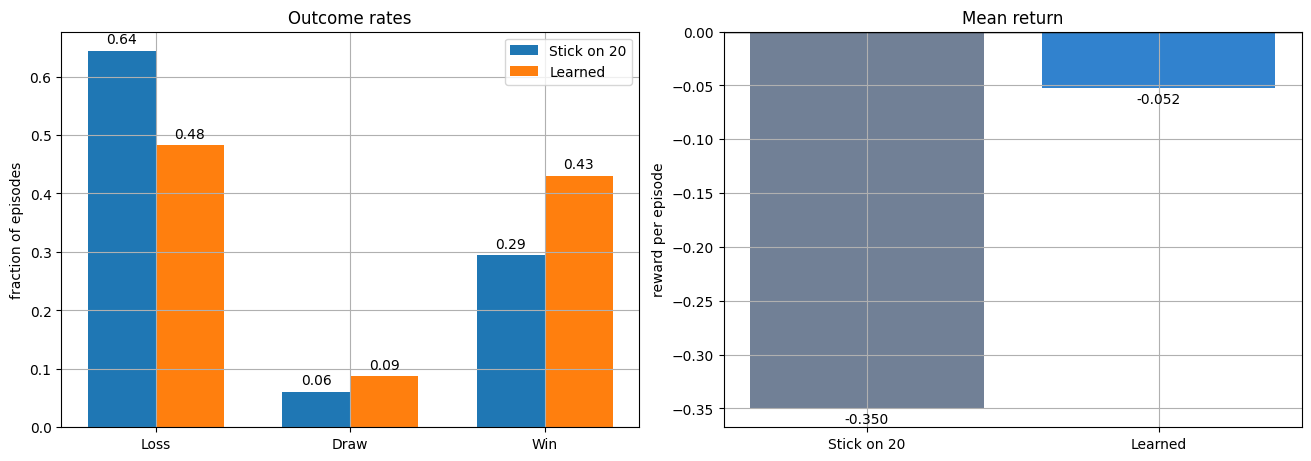

In [14]:
labels = ["Loss", "Draw", "Win"]
metric_keys = ["loss_rate", "draw_rate", "win_rate"]
colours = ["#e53e3e", "#a0aec0", "#38a169"]
x = np.arange(len(labels))
width = 0.35

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

for offset, (name, metrics) in zip([-width / 2, width / 2], evaluation.items()):
    values = [metrics[key] for key in metric_keys]
    bars = axs[0].bar(x + offset, values, width, label=name)
    axs[0].bar_label(bars, fmt="%.2f", padding=3)

axs[0].set_title("Outcome rates")
axs[0].set_xticks(x, labels)
axs[0].set_ylabel("fraction of episodes")
axs[0].legend()

return_bars = axs[1].bar(
    list(evaluation),
    [metrics["mean_return"] for metrics in evaluation.values()],
    color=["#718096", "#3182ce"],
)
axs[1].bar_label(return_bars, fmt="%.3f", padding=3)
axs[1].axhline(0, color="black", linewidth=1)
axs[1].set_title("Mean return")
axs[1].set_ylabel("reward per episode")

plt.show()


### What you should notice

- The learned policy loses less often and wins more often than the simple baseline.
- Its expected return still remains slightly negative; blackjack remains an unfavourable game under these rules.
- Monte Carlo control improves behaviour without ever receiving the transition probabilities.
- The policy is only as reliable as its state-action coverage and number of episodes.

<br>
<br>
<hr>
<br>
<br>


# 10. Extension: Could RL Learn to Beat the House?

Our learned policy wins about `43%` of hands, so a tempting next question is:

> Could a more advanced agent push its win rate above `50%`?

That is engaging, but **win rate is not quite the right objective**. Blackjack includes draws, and real blackjack can pay different amounts for blackjack, doubling, splitting, and other actions. A player could win fewer than half of all hands and still have positive expected return if the wins pay enough. The more useful question is:

> Could an agent achieve positive expected return after accounting for stakes and payouts?

### Why variable betting cannot help in our current environment

Blackjack-lite uses an infinite deck. Every card draw is independent, so the card distribution resets conceptually after each draw. Before a new hand, the agent has no information suggesting that the next hand is unusually favourable.

Betting more in some randomly selected hands would increase the size of wins and losses, but it would not improve expected return. It would only increase variance.

### What changes with a finite shoe?

Real tables often deal from a shoe containing several decks. As cards are revealed, the composition of the remaining shoe changes.

For example, a shoe containing an unusually high proportion of tens and aces can be more favourable to the player. A strategy could then:

- bet the minimum when the remaining shoe favours the dealer
- bet more when the estimated player advantage becomes positive
- still choose hit, stick, double, or split based on the current hand

This is the basic statistical idea behind card counting.

### A richer RL state

The exact hidden order of the shoe should not be included in the state because the player cannot observe it. A useful observable state could include:

```text
remaining counts for card values 1–10
player hand
dealer's visible card
current bankroll
current bet
```

The decision process would also have two phases:

1. choose a stake before cards are dealt
2. choose playing actions after seeing the initial hand

The reward could be the change in bankroll after each hand.

### Why tabular Monte Carlo would struggle

Our current table has only 200 blackjack states. A finite shoe creates an enormous number of possible card-count combinations. Adding bankroll, bet size, pairs, doubling, and splitting expands it further.

Most exact states would be visited rarely, so a table would learn each one almost independently and generalise poorly.

This creates a natural motivation for **function approximation**:

- a linear model could learn from compressed features such as a running or true count
- a neural network could learn similarities between different shoe compositions
- a deep-RL agent could jointly learn bet sizing and playing decisions

Deep RL would not automatically produce a profitable system. It would still need realistic rules, enough simulated experience, careful evaluation on unseen shoes, and comparisons with strong baselines such as basic strategy and a conventional card-counting system.

### A possible later project

A future extension could compare:

1. fixed bets with the policy learned in this chapter
2. a hand-coded card-counting and bet-spread strategy
3. a linear value-function agent using count features
4. a neural agent using the remaining-card composition

The objective should also account for bankruptcy risk. Maximising raw short-term money may encourage reckless maximum bets. Alternatives include constrained bet sizes or maximising expected log-bankroll growth.

This would make a useful function-approximation, deep-RL, or capstone project because it demonstrates exactly why tabular methods stop scaling.

> **Practical note:** this is an educational simulation idea, not a reliable gambling strategy. Casino rules, payouts, reshuffling, betting limits, and variance all materially affect the result.

<br>
<br>
<hr>
<br>
<br>


# 11. Diving Deeper

### 10.1 First-visit versus every-visit

If a state appears more than once in an episode:

- **first-visit MC** updates it from the return following its first occurrence
- **every-visit MC** updates it after every occurrence

Both converge under standard assumptions. First-visit MC maps cleanly to “one return sample per state per episode”, while every-visit MC can reuse more observations.

### 10.2 Exploring starts

Classic Monte Carlo control can assume **exploring starts**:

- every state-action pair has some chance of being the episode's starting pair

This guarantees broad coverage, but it is often unrealistic. We instead used an epsilon-soft policy so exploration happens during naturally generated episodes.

### 10.3 Why Monte Carlo does not bootstrap

The target is the observed full return:

$$
G_t=R_{t+1}+\gamma R_{t+2}+\cdots+R_T.
$$

It does not include a current estimate such as $V(S_{t+1})$. This avoids bootstrap bias but usually produces higher-variance targets.

### 10.4 Limitations

Monte Carlo methods:

- must wait for episode termination
- can require many samples
- struggle with rare states
- are not directly suited to continuing tasks without artificial episode boundaries

The next chapter introduces TD learning, which updates earlier by combining sampling with bootstrapping.

### If you want to go deeper

- Sutton & Barto (2018), Chapter 5
- David Silver's lecture on model-free prediction and control

<br>
<br>
<hr>
<br>
<br>


# 12. Knowledge Check

### Tier 1: concept checks (5–10 minutes)

1. Why must Monte Carlo wait until the episode ends?
2. What is used as the update target in first-visit MC prediction?
3. Why should visit counts be shown alongside value estimates?
4. Why are action values needed for control?
5. What role does epsilon play during Monte Carlo control?
6. How does Monte Carlo differ from Chapter 04's value iteration?

### Tier 2: small coding change (15–30 minutes)

Choose one:

- Compare prediction after `1,000`, `10,000`, and `50,000` episodes.
- Change the fixed policy to stick on `19` and compare its value heatmaps.
- Train control with `epsilon = 0.01` and `epsilon = 0.3`.
- Replace first-visit updates with every-visit updates.

State your prediction before running the experiment.

### Tier 3: extension (30–60 minutes)

Choose one:

- use a decaying epsilon schedule and compare the final policy
- add a `double` action with a doubled terminal reward
- evaluate how stable the learned policy is across five random seeds

Explain how your change affects exploration, state-action coverage, or return variance.

<br>
<br>
<hr>
<br>
<br>


# 13. Takeaways

- Monte Carlo methods learn from complete sampled episodes without a transition model.
- First-visit prediction averages full returns following the first visit to each state.
- Visit counts reveal where estimates are well supported and where they remain uncertain.
- More episodes generally reduce sampling error, but rare states learn slowly.
- Monte Carlo control estimates action values and improves decisions with epsilon-soft exploration.
- The learned blackjack policy improves substantially over the fixed baseline.
- Monte Carlo does not bootstrap, so its targets are complete but often high variance.

### Common pitfalls

- updating before the final outcome is known
- confusing first-visit with the last occurrence found during a backwards loop
- treating a low-visit estimate as equally reliable as a high-visit estimate
- removing exploration before both actions have useful coverage
- evaluating with exploratory actions when measuring the final greedy policy

<br>
<br>
<hr>
<br>
<br>

# 14. What's Next

- Next notebook: **Temporal-difference learning**, where values update after each transition rather than waiting for complete episodes.
- Suggested reading: Sutton & Barto (2018), Chapters 5 and 6.

<br>
<br>
<hr>
<br>
<br>


In [15]:
######################################################################
######################## ANSWERS BELOW ###############################
######################################################################
######################## ANSWERS BELOW ###############################
######################################################################
######################## ANSWERS BELOW ###############################
######################################################################


## Answer to the First-Visit Monte Carlo Exercise

```python
def first_visit_mc_update(trajectory, values, counts, gamma=1.0):
    rewards = [transition[2] for transition in trajectory]
    returns = returns_from_rewards(rewards, gamma)
    visited_states = set()

    for (state, _, _), G in zip(trajectory, returns):
        if state in visited_states:
            continue

        visited_states.add(state)
        counts[state] += 1
        values[state] += (G - values[state]) / counts[state]
```

<hr style="border: none; border-top: 2px dashed #999; margin: 24px 0;">

## Answers to Concept Checks

### 1. Why must Monte Carlo wait until the episode ends?

Its target is the complete return, which cannot be known until all later rewards have been observed.

### 2. What is the update target?

The discounted return following the state's first occurrence in that episode.

### 3. Why show visit counts?

They indicate how much data supports each estimate. Rare states generally have noisier values.

### 4. Why are action values needed for control?

A state value says how good a state is under a policy, but it does not directly compare the available actions. Action values support greedy policy improvement.

### 5. What role does epsilon play?

It preserves exploration by sometimes choosing a random action, ensuring the agent continues gathering evidence about alternatives.

### 6. How does Monte Carlo differ from value iteration?

Monte Carlo averages returns from sampled episodes without a model. Value iteration calculates expected backups using known transition probabilities and rewards.
